# Titanic - final score 0.82296

Welcome to Kaggle's Titanic!
There surely are a lot of guides on Kaggle's Titanic, so you probably should not expect any novel ideas here. This writeup is more for me and my friends, but maybe you'll find it interesting as well.

Since the dataset is fairly small and noisy it's important to not overfit on the training data. To add to that: If you don't spend time on feature engineering, your model will not (or just barely) beat the baseline score of `~76.5%` accuracy that the simple "man dies, woman lives" model achieves. Simply piping the raw data into a model of your choice will not get you a good result!

Regarding feature exploration and plots:
While feature exploration in a visual way is no doubt an important part of the process, there are lots of guides doing exactly that. This notebook is about creating a well-performing model, not about feature exploration.

Regarding models: I've tried a bunch of models (random forest, logistic regression, support vector classifier, k-nearest neighbours, extra trees, xgboost, ...) and after some testing the following three performed the best:

- Random Forest
- Extra Trees
- XGBoost

Each of those models (after feature engineering(!) and hyperparameter tuning) achieves `80%+` accuracy. The final result of `~82.2%` was achieved by combining all three into a weighted soft voting ensemble.

In the end the following features were used:

- Title
- Embarked
- Sex
- Pclass
- HasCabin
- IsChild (Age < 12.0)
- AgeMissing
- SmallGroup (Group size by ticket between 2 and 4 (both included))
- FamSize (Family Size)
- Age
- FarePerPerson (log-scaled, although this does not matter for tree-based models)
- Survival Rate (of the group, either by surname or by ticket, mean if both could be calculated)


In [18]:
import os
import random

from IPython.core.magic import register_cell_magic

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
)
from xgboost import XGBClassifier

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    StratifiedKFold,
    ParameterGrid,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
)

In [19]:
# Skip cell magic. Annotate a cell with `%%skip` at the top and it will skip.
# Used to not run hyperparameter search every time.
@register_cell_magic
def skip(line, cell):
    print("-> Skipping this cell.")

# Reading the input


In [20]:
train = pd.read_csv("./data/titanic/train.csv")
labels = train["Survived"]
train.drop("Survived", axis=1, inplace=True)
train.drop("PassengerId", axis=1, inplace=True)

test = pd.read_csv("./data/titanic/test.csv")

# Needed later on to write test output
test_ids = test["PassengerId"]
test.drop("PassengerId", axis=1, inplace=True)

combined = pd.concat([train, test])
combined.reset_index(drop=True, inplace=True)

# Notice some missing features? We'll come back to that!
combined.isnull().sum()

Pclass         0
Name           0
Sex            0
Age          263
SibSp          0
Parch          0
Ticket         0
Fare           1
Cabin       1014
Embarked       2
dtype: int64

# Feature engineering

Feature engineering is probably the most important part of this challenge. We'll do multiple things:

- Extract surname and title from 'Name'
- Add missing features for the 'Embarked', 'Cabin', 'Age' and 'Fare' columns
- Extract family information like size and whether people are alone
- Extract the cabin letters and whether people have a cabin
- Extract ticket information like group sizes, ticket prefixes and fare per person (since tickets can be for multiple people!)
- Survival rate (rate of survival in a group - either by ticket or by surname, if both are present the mean is taken)


## Extract surname, title


In [21]:
for df in [test, train, combined]:
    df[["Surname", "Title"]] = df["Name"].str.extract(r"(?P<Surname>[A-Za-z]+),\s(?P<Title>[A-Za-z\s]+)\.", expand=True)
    df["Title"] = df["Title"].replace(["Miss", "Mlle"], "Ms")
    df["Title"] = df["Title"].replace("Mme", "Mrs")

    df["Title"] = df["Title"].replace(["Lady", "Sir", "the Countess", "Jonkheer", "Rev", "Don", "Dona"], "Nobility")
    df["Title"] = df["Title"].replace(["Capt", "Col", "Major", "Dr"], "Military")

combined["Title"].unique()

array(['Mr', 'Mrs', 'Ms', 'Master', 'Nobility', 'Military'], dtype=object)

## Adding missing features


In [22]:
# Adding missing 'Embarked'
print(combined[combined["Embarked"].isna()]["Name"])

# Google search reveals that both boarded the titanic in Southhampton
for df in [train, test, combined]:
    df["Embarked"] = df["Embarked"].fillna("S")

# Adding missing 'Cabin': U for unknown
for df in [train, test, combined]:
    df["Cabin"] = df["Cabin"].fillna("U")

# Adding missing 'Age'
for df in [train, test, combined]:
    df["AgeMissing"] = (df["Age"].isnull()).astype(int)
    df["Age"] = df["Age"].fillna(df.groupby(["Sex", "Pclass", "Title"])["Age"].transform("median"))

# Adding missing 'Fare' - there is only one person missing it!
storey = combined[combined["Fare"].isnull()]
print(storey)

# Let's see how many match his attributes
cols = ["Pclass", "Sex", "Cabin", "Embarked", "SibSp", "Parch"]
mask = (combined[cols] == storey[cols].iloc[0]).all(axis=1)

matching_storey = combined[mask]

# Use the median of "all passengers like storey"
for df in [train, test, combined]:
    df["Fare"] = df["Fare"].fillna(matching_storey["Fare"].median())

combined.loc[storey.index]

61                           Icard, Miss. Amelie
829    Stone, Mrs. George Nelson (Martha Evelyn)
Name: Name, dtype: object
      Pclass                Name   Sex   Age  SibSp  Parch Ticket  Fare Cabin  \
1043       3  Storey, Mr. Thomas  male  60.5      0      0   3701   NaN     U   

     Embarked Surname Title  AgeMissing  
1043        S  Storey    Mr           0  


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,AgeMissing
1043,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,7.8958,U,S,Storey,Mr,0


## Extract family info, group cabins


In [23]:
# Extract family info
for df in [test, train, combined]:
    df["FamSize"] = df["SibSp"] + df["Parch"] + 1
    df["Alone"] = (df["FamSize"] == 1).astype(int)

# Group cabins
for df in [test, train, combined]:
    df["Cabin"] = df["Cabin"].str.extract(r"([A-Za-z]+)", expand=True)
    df["HasCabin"] = (df["Cabin"] != "U").astype(int)

## Ticket feature engineering

Quite a lot of information can be gained from the ticket. Early on, I made the mistake of largely ignoring this column. However, you should not discard it so easily, there is some value to be gained here!


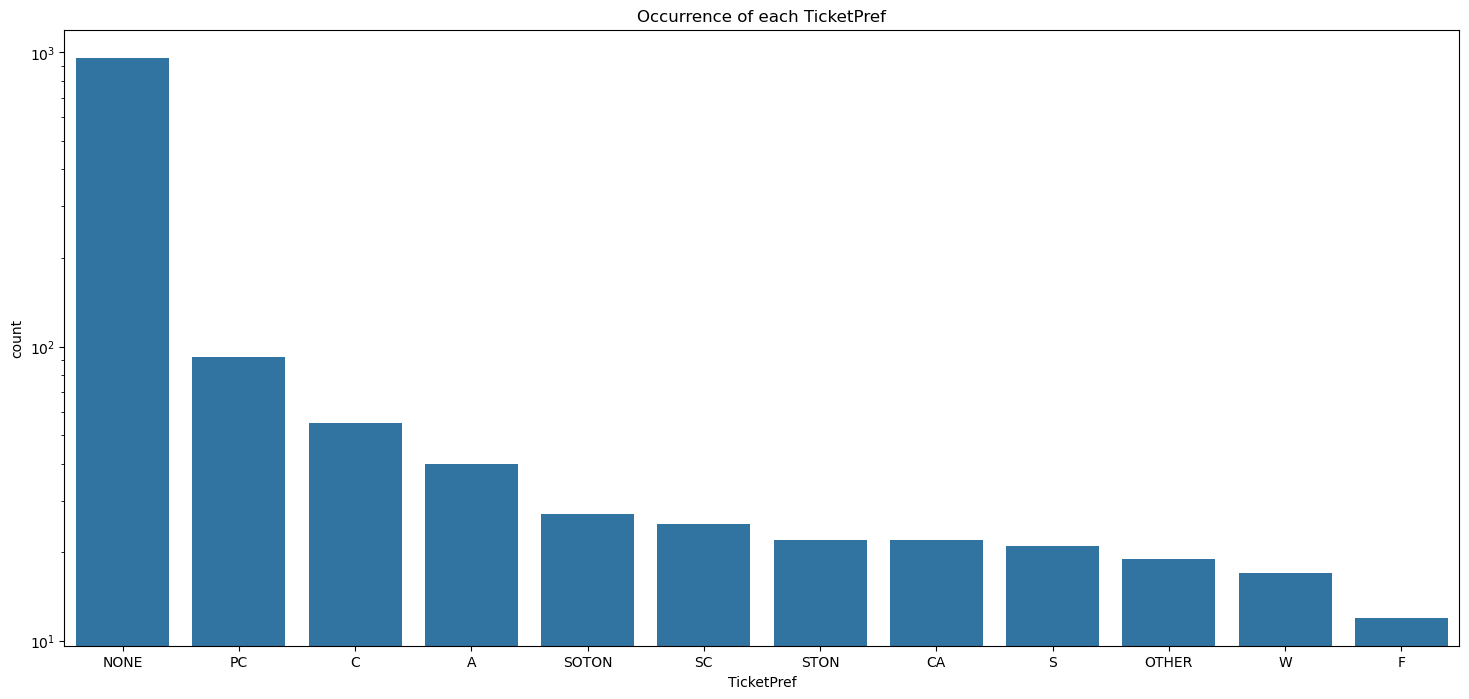

In [24]:
for df in [test, train, combined]:
    df["GroupSize"] = combined.groupby("Ticket")["Ticket"].transform("count")
    df["SmallGroup"] = ((df["GroupSize"] > 1) & (df["GroupSize"] < 5)).astype(int)
    df["LargeGroup"] = (df["GroupSize"] > 4).astype(int)

    df["TicketPref"] = df["Ticket"].str.extract(r"([A-Za-z]+)", expand=True)
    df["TicketPref"] = df["TicketPref"].fillna("NONE")

    freq = df["TicketPref"].value_counts()
    rare = freq[freq < 10].index
    df["TicketPref"] = df["TicketPref"].replace(rare, "OTHER")

    # Some tickets have two prices attached - take the mean in that case
    df["FarePerPerson"] = df.groupby("Ticket")["Fare"].transform("mean") / df["GroupSize"]

fig, ax = plt.subplots(figsize=(18, 8))
sns.countplot(
    x="TicketPref",
    data=combined,
    order=combined["TicketPref"].value_counts().index,
    ax=ax,
)

ax.set_title("Occurrence of each TicketPref")
ax.set_yscale("log")

plt.show()

## Bucketing Fare Cost, Ages

For some models (especially linear models, like logistic regression) it can be worth it to bucket continuous features. Of course, this is not needed for e.g. tree-based models.


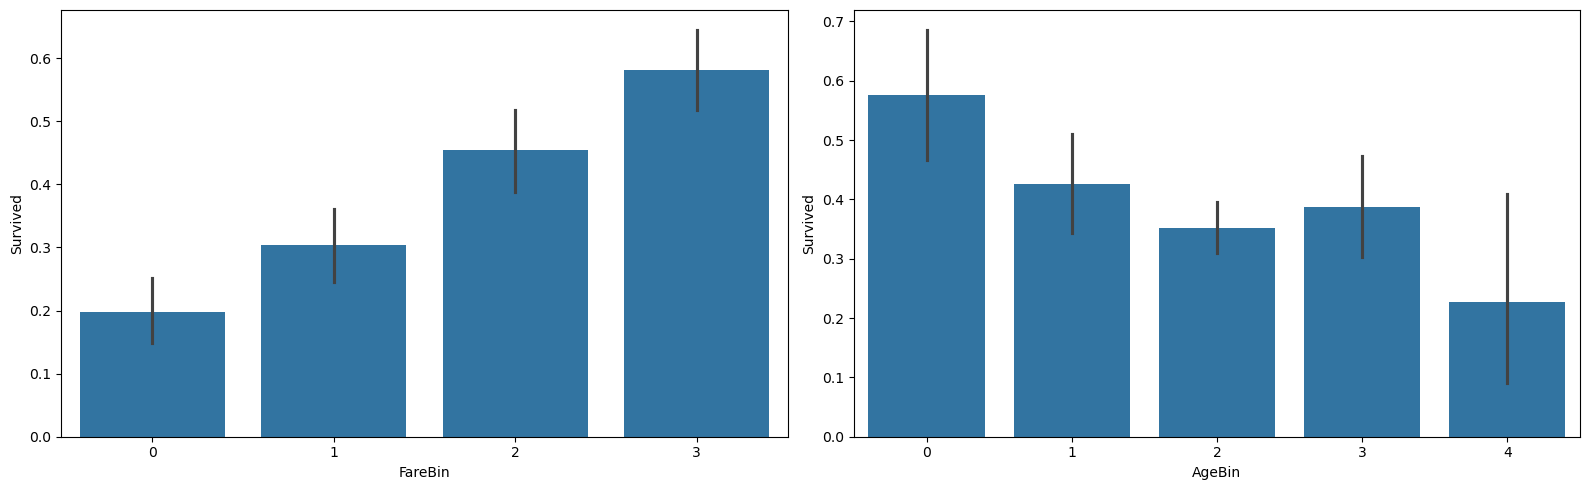

In [25]:
for df in [test, train, combined]:
    # 4 seems good according to the plot below
    df["FareBin"] = pd.qcut(df["Fare"], 4, labels=False, duplicates="drop")

    df["AgeBin"] = pd.cut(df["Age"], bins=[-1, 12, 20, 40, 60, 120], labels=False)
    df["IsChild"] = (df["Age"] < 12.0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x="FareBin", y=labels, data=train, ax=axes[0])
sns.barplot(x="AgeBin", y=labels, data=train, ax=axes[1])

plt.tight_layout()
plt.show()

## Adding survival rate

Survival rate is a hugely important feature - BUT one has to be careful how to calculate it. I used leave-one-out-encoding to calculate it in a leakage-free way for both train and test data.

However, one has to recalculate it for each split when evaluating ones models. Otherwise the information will leak into the models **and the models WILL OVERFIT!**


In [26]:
# Calculates the survival rate for X_train and X_val in a leakage-free way
def add_survival_rate(X_train, X_val, y_train):
    family_stats = y_train.groupby(X_train["Surname"]).agg(["sum", "count"])
    ticket_stats = y_train.groupby(X_train["Ticket"]).agg(["sum", "count"])
    survived_mean = y_train.mean()

    # Calculcate X_train survival rate via leave-one-out encoding
    X_train["FamSurvivalRate"] = (X_train["Surname"].map(family_stats["sum"]) - y_train) / (
        X_train["Surname"].map(family_stats["count"]) - 1
    )
    X_train["TicketSurvivalRate"] = (X_train["Ticket"].map(ticket_stats["sum"]) - y_train) / (
        X_train["Ticket"].map(ticket_stats["count"]) - 1
    )

    # Calculate X_val survival rate
    X_val["FamSurvivalRate"] = X_val["Surname"].map(family_stats["sum"]) / X_val["Surname"].map(family_stats["count"])
    X_val["TicketSurvivalRate"] = X_val["Ticket"].map(ticket_stats["sum"]) / X_val["Ticket"].map(ticket_stats["count"])

    for df in [X_train, X_val]:
        df["SurvivalRate"] = df[["FamSurvivalRate", "TicketSurvivalRate"]].mean(axis=1)
        df["SurvivalRate"] = df["SurvivalRate"].fillna(survived_mean)
        df.drop(["FamSurvivalRate", "TicketSurvivalRate"], axis=1, inplace=True)


add_survival_rate(train, test, labels)

In [27]:
for df in [train, test, combined]:
    # We've extracted all useful data from the Name column
    df.drop("Name", axis=1, inplace=True)

    # Fare correlates highly with FarePerPerson
    df.drop(["Fare"], axis=1, inplace=True)
    # FareBin, AgeBin correlate (obviously) with Fare and Age and for tree-based models it does not make sense to bin it
    df.drop(["FareBin", "AgeBin"], axis=1, inplace=True)

    # Parch, SibSp, GroupSize correlate highly with FamSize
    df.drop(["Parch", "SibSp", "GroupSize"], axis=1, inplace=True)

    # LargeGroup, Alone correlate highly with FamilySize
    df.drop(["LargeGroup", "Alone"], axis=1, inplace=True)

    # HasCabin is probably more accurate than those two
    df.drop(["Cabin", "TicketPref"], axis=1, inplace=True)

    # Special is probably accurate enough
    df["Title"] = df["Title"].replace(["Nobility", "Military"], "Special")

    # Log-scale FarePerPerson to get rid of the huge outliers - doesn't actually matter for the tree-based models
    df["FarePerPerson"] = np.log(1 + df["FarePerPerson"])

# Do not drop Ticket, Surname because we still have to calculate SurvivalRate dynamically

# Flush cleaned output to FS

Here we flush the cleaned data once to the filesystem, so we can reload a clean state for development purposes.


In [28]:
# Allows to just reload the cleaned data, no need to run above cells all the time
os.mkdir("./data/titanic/cleaned")
train.to_csv("./data/titanic/cleaned/train.csv", index=False)
test.to_csv("./data/titanic/cleaned/test.csv", index=False)

# Reload the data

Reload the data from the filesystem and create a copy of the training data. This copy will be used to dynamically calculate survival rate for cross-validation to prevent data leakage and therefore overfitting of the models.


In [29]:
# Reload data from FS
train = pd.read_csv("./data/titanic/cleaned/train.csv")
test = pd.read_csv("./data/titanic/cleaned/test.csv")
test_ids = pd.read_csv("./data/titanic/test.csv")["PassengerId"]
labels = pd.read_csv("./data/titanic/train.csv")["Survived"]

# Second data set which is used to compute accurate survival score without data leakage
train2 = train.copy(deep=True)
train2.drop(["SurvivalRate"], axis=1, inplace=True)

for df in [train, test]:
    # No longer needed since they are way too specific - we only needed them for train2
    df.drop(["Ticket", "Surname"], axis=1, inplace=True)

train.columns

Index(['Pclass', 'Sex', 'Age', 'Embarked', 'Title', 'AgeMissing', 'FamSize',
       'HasCabin', 'SmallGroup', 'FarePerPerson', 'IsChild', 'SurvivalRate'],
      dtype='object')

# Creating the models


In [164]:
def create_pipeline(model):
    hot = ["Title", "Embarked"]
    ordinal = ["Sex", "Pclass", "HasCabin", "IsChild", "AgeMissing", "SmallGroup"]
    std_scale = ["FamSize", "Age", "FarePerPerson", "SurvivalRate"]
    preprocessor = ColumnTransformer(
        transformers=[
            ("hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), hot),
            ("label", OrdinalEncoder(), ordinal),
            ("std-scaler", StandardScaler(), std_scale),
        ]
    )

    return Pipeline([("preprocess", preprocessor), ("model", model)])


# Helper methods to define models with optimal hyperparameters (as determined later) that can be reused everywhere
def get_rfc(oob=False):
    rfc = RandomForestClassifier(
        criterion="entropy",
        max_depth=20,
        max_features="log2",
        min_samples_leaf=4,
        min_samples_split=4,
        n_estimators=100,
        random_state=0,
        oob_score=oob,
    )
    return create_pipeline(rfc)


def get_etc(oob=False):
    etc = ExtraTreesClassifier(
        criterion="entropy",
        max_depth=20,
        max_features="sqrt",
        min_samples_leaf=1,
        min_samples_split=10,
        n_estimators=300,
        random_state=0,
        oob_score=oob,
    )
    return create_pipeline(etc)


def get_xgb(oob=False):
    xgb = XGBClassifier(
        colsample_bytree=1.0,
        gamma=0,
        learning_rate=0.01,
        max_depth=3,
        min_child_weight=1,
        n_estimators=500,
        reg_alpha=0,
        reg_lambda=5,
        subsample=0.8,
        oob_score=oob,
    )
    return create_pipeline(xgb)

# Identifying important features

I used this section to iteratively identify unimportant features and remove them from the models. Now, it only visualizes what's left. But for me it was an important part of the development process to reduce the number of features to avoid overfitting.

To identify which features are actually important I did two things:

- Get a correlation matrix of the features and reduce those with minimal predictive power, as well as features that are highly correlated
- Get the feature importances of the rfc to determine which features are used by the model to make decisions

For example `hot__Title_Mr` is highly correlated with `Sex` (.86) but the random forest classifier uses both highly to make decision. As a consequence, neither was removed. The goal here is to remove features that have no or minimal predictive power so we do not overfit and the model generalizes well.


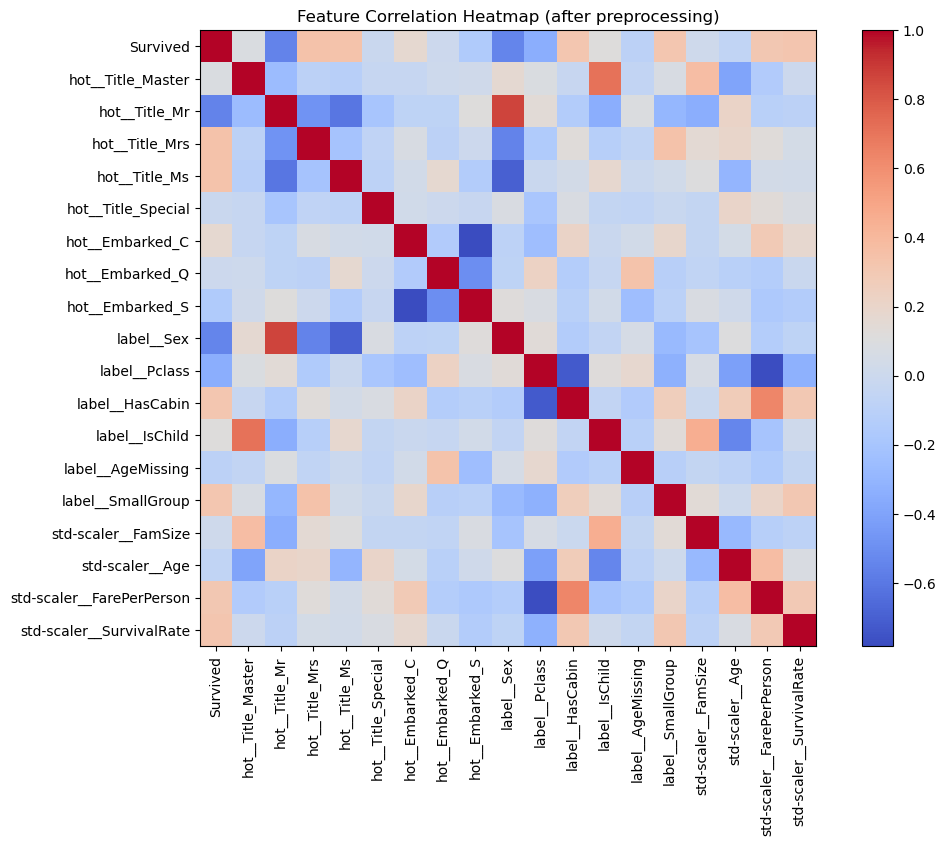

18 features left!


,Survived,hot__Title_Master,hot__Title_Mr,hot__Title_Mrs,hot__Title_Ms,hot__Title_Special,hot__Embarked_C,hot__Embarked_Q,hot__Embarked_S,label__Sex,label__Pclass,label__HasCabin,label__IsChild,label__AgeMissing,label__SmallGroup,std-scaler__FamSize,std-scaler__Age,std-scaler__FarePerPerson,std-scaler__SurvivalRate
Survived,1.000000,0.085221,-0.549199,0.341994,0.335636,-0.012054,0.168240,0.003650,-0.149683,-0.543351,-0.338481,0.316912,0.113161,-0.092197,0.315591,0.016639,-0.062900,0.306219,0.321518
hot__Title_Master,0.085221,1.000000,-0.254903,-0.087987,-0.110981,-0.035291,-0.035225,0.010478,0.024264,0.159934,0.082081,-0.027841,0.711321,-0.053607,0.071620,0.372472,-0.395772,-0.144664,-0.000661
hot__Title_Mr,-0.549199,-0.254903,1.000000,-0.477160,-0.601857,-0.191387,-0.072567,-0.078338,0.112870,0.867334,0.142698,-0.137319,-0.340261,0.092886,-0.288758,-0.338014,0.208576,-0.100583,-0.090100
hot__Title_Mrs,0.341994,-0.087987,-0.477160,1.000000,-0.207749,-0.066063,0.067872,-0.090432,-0.002550,-0.550146,-0.153758,0.123817,-0.120331,-0.064827,0.340359,0.153842,0.197872,0.123537,0.051465
hot__Title_Ms,0.335636,-0.110981,-0.601857,-0.207749,1.000000,-0.083327,0.036204,0.167531,-0.137144,-0.693916,-0.010261,0.043749,0.173109,-0.005207,0.030515,0.107500,-0.300256,0.039336,0.034554
hot__Title_Special,-0.012054,-0.035291,-0.191387,-0.066063,-0.083327,1.000000,0.030095,0.000311,-0.026561,0.075638,-0.187174,0.079742,-0.048265,-0.063309,-0.020795,-0.047426,0.200880,0.129865,0.079798
hot__Embarked_C,0.168240,-0.035225,-0.072567,0.067872,0.036204,0.030095,1.000000,-0.148258,-0.782742,-0.082853,-0.243292,0.208528,-0.016590,0.033270,0.187833,-0.046215,0.048652,0.288840,0.171902
hot__Embarked_Q,0.003650,0.010478,-0.078338,-0.090432,0.167531,0.000311,-0.148258,1.000000,-0.499421,-0.074115,0.221009,-0.129572,-0.032569,0.337413,-0.109236,-0.058592,-0.105471,-0.132930,-0.014684
hot__Embarked_S,-0.149683,0.024264,0.112870,-0.002550,-0.137144,-0.026561,-0.782742,-0.499421,1.000000,0.119224,0.074053,-0.101139,0.035029,-0.241480,-0.095807,0.077359,0.023752,-0.169383,-0.141353
label__Sex,-0.543351,0.159934,0.867334,-0.550146,-0.693916,0.075638,-0.082853,-0.074115,0.119224,1.000000,0.131900,-0.140391,-0.057120,0.055215,-0.273690,-0.200988,0.103189,-0.133428,-0.075359


In [74]:
def print_corr(X_train, labels, feature_names):
    # Convert transformed array back to DataFrame
    X_train_df = pd.DataFrame(X_train, columns=feature_names)
    X_train_df = pd.concat([labels, X_train_df], axis=1)

    # Correlation matrix
    corr_matrix = X_train_df.corr()

    plt.figure(figsize=(12, 8))
    plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
    plt.colorbar()
    plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
    plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
    plt.title("Feature Correlation Heatmap (after preprocessing)")
    plt.show()

    print(f"{len(feature_names)} features left!")
    return corr_matrix


rfc = get_rfc()
rfc.fit(train, labels)

feature_names = rfc["preprocess"].get_feature_names_out()
print_corr(rfc[:-1].transform(train), labels, feature_names)

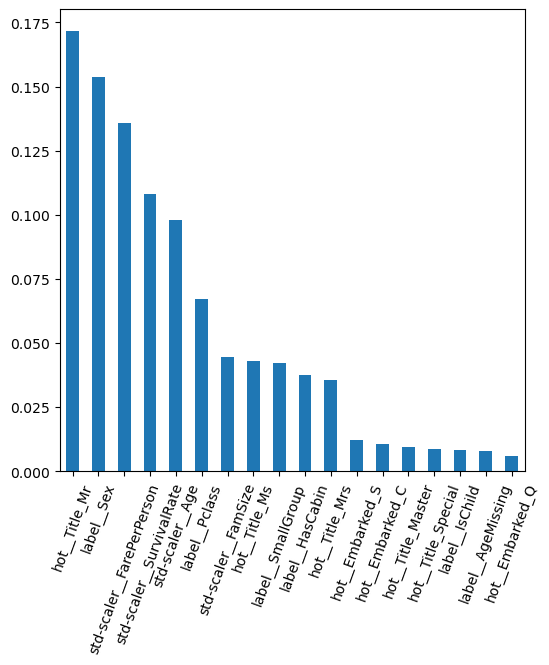

In [87]:
rfc = get_rfc()
rfc.fit(train, labels)

feature_names = rfc["preprocess"].get_feature_names_out()

importances = pd.Series(rfc["model"].feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

importances.plot.bar()
ax = importances.plot.bar()

fig = plt.gcf()
fig.set_size_inches(6, 6)

plt.xticks(rotation=70)
plt.show()

# Evaluating models

Of course we want to evaluate our models to decide early which ones to drop and which ones might be worth a shot. Since we want to avoid target leakage of the survival rate we cannot use the standard cv score. Hence `custom_val_score` was created.


In [165]:
def custom_val_score(clf, X, y, score_func=balanced_accuracy_score):
    # Use stratified k-fold because of the slight imbalance 38/62
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    scores = []

    for train_idx, val_idx in skf.split(train, labels):
        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

        # Calculate the validations survival rate with the train set only
        add_survival_rate(X_train, X_val, y_train)
        clf.fit(X_train, y_train)
        scores.append(score_func(y_val, clf.predict(X_val)))

    return np.array(scores)


def evaluate(clf):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    acc_scores = custom_val_score(clf, train2, labels, accuracy_score)
    bal_scores = custom_val_score(clf, train2, labels, balanced_accuracy_score)
    print(
        f"[Accuracy] Mean: {round(acc_scores.mean() * 100, 2)}%, standard deviation: {round(acc_scores.std() * 100, 2)}%"
    )
    print(
        f"[Balanced] Mean: {round(bal_scores.mean() * 100, 2)}%, standard deviation: {round(bal_scores.std() * 100, 2)}%"
    )

    print("Evalute:", clf)


for clf in [get_rfc(), get_etc(), get_xgb()]:
    evaluate(clf)

[Accuracy] Mean: 84.06%, standard deviation: 2.39%
[Balanced] Mean: 82.0%, standard deviation: 2.42%
Evalute: Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('hot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Title', 'Embarked']),
                                                 ('label', OrdinalEncoder(),
                                                  ['Sex', 'Pclass', 'HasCabin',
                                                   'IsChild', 'AgeMissing',
                                                   'SmallGroup']),
                                                 ('std-scaler',
                                                  StandardScaler(),
                                                  ['FamSize', 'Age',
                                                   '

# Hyperparameter tuning

Once we decided on which models to use we want to tune the hyperparameters. Since the Titanic data set is small and also slightly noisy this usually does not give a huge boost. Furthermore, one always has to be careful about overfitting. Make sure to define the search space accordingly!

`get_optimal_parms` does a (randomized) grid search of the parameter space. It's needed to avoid target leakage of the survival rate column.


In [166]:
# Uses random sampling since no one got time for the whole parameter search
def get_optimal_params(clf, X, y, param_grid, n_samples=100):
    pg = list(ParameterGrid(param_grid))
    if len(pg) > n_samples:
        print(f"Selecting {n_samples} random features of {len(pg)} total configurations.")
        pg = random.sample(pg, n_samples)

    results = []
    for param in pg:
        model = clone(clf)
        model.set_params(**param)
        scores = custom_val_score(model, X, y)
        results.append(scores.mean())

    best_idx = np.argmax(results)
    return (results[best_idx], pg[best_idx])

## Tuning RFC


In [167]:
%%skip

param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__n_estimators": [100, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 4, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

score, params = get_optimal_params(get_rfc(), train2, labels, param_grid)

print(f"Best parameters: {params}")
print(f"Best CV score: {score}")

# Best parameters: {'model__criterion': 'entropy', 'model__max_depth': 20, 'model__max_features': 'log2', 'model__min_samples_leaf': 4, 'model__min_samples_split': 4, 'model__n_estimators': 100}
# Best CV score: 0.8199731909299238

-> Skipping this cell.


## Tuning Extra Trees


In [168]:
%%skip

param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__n_estimators": [100, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 4, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

(score, params) = get_optimal_params(get_etc(), train2, labels, param_grid, n_samples=300)

print(f"Best parameters: {params}")
print(f"Best CV score: {score}")

# Best parameters: {'model__criterion': 'entropy', 'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 300}
# Best CV score: 0.8191196983561891

-> Skipping this cell.


## Tuning XGBoost


In [169]:
%%skip

param_grid = {
    # Tree complexity
    # Do not set max_depth too high to avoid overfitting
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__gamma": [0, 0.1, 0.3, 0.5],
    # Sampling
    "model__subsample": [0.4, 0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    # Boosting and learning
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__n_estimators": [100, 300, 500],
    # Regularization
    "model__reg_lambda": [0, 1, 5, 10],
    "model__reg_alpha": [0, 0.1, 1, 5],
}

(score, params) = get_optimal_params(get_xgb(), train2, labels, param_grid, n_samples=500)

print(f"Best parameters: {params}")
print(f"Best CV score: {score}")

# Best parameters: {'model__colsample_bytree': 1.0, 'model__gamma': 0, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 500, 'model__reg_alpha': 0, 'model__reg_lambda': 5, 'model__subsample': 0.8}
# Best CV score: 0.8291063204844618

-> Skipping this cell.


# Making predictions


In [170]:
# Helper function
def predict(clf, out_name):
    clf.fit(train, labels)
    predicted = clf.predict(test)

    out_df = pd.DataFrame(data={"PassengerId": test_ids, "Survived": predicted})
    out_df.to_csv(f"./data/output/{out_name}", index=False)
    print("Output written!")


# 0.81339
predict(get_rfc(), "predicted-rfc.csv")

# 0.80861
predict(get_etc(), "predicted-etc.csv")

# 0.80861
predict(get_xgb(), "predicted-xgb.csv")

Output written!
Output written!
[16:48:14] WARNING: D:\bld\xgboost-split_1700182179651\work\src\learner.cc:767: 
Parameters: { "oob_score" } are not used.

Output written!


# Ensembles

We now have three well-performing (~81%) models. The final step in our solution is to combine these in a **soft voting ensemble** in the hopes of achieving an even higher score.


In [171]:
estimators = [("rfc", get_rfc()), ("etc", get_etc()), ("xgb", get_xgb())]

# Sanity checks
print("estimators structure:", [(name, type(est)) for name, est in estimators])

estimators structure: [('rfc', <class 'sklearn.pipeline.Pipeline'>), ('etc', <class 'sklearn.pipeline.Pipeline'>), ('xgb', <class 'sklearn.pipeline.Pipeline'>)]


In [135]:
def custom_val_score(clf, X, y, score_func=balanced_accuracy_score):
    # Use stratified k-fold because of the slight imbalance 38/62
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    scores = []

    for train_idx, val_idx in skf.split(train, labels):
        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

        # Calculate the validations survival rate with the train set only
        add_survival_rate(X_train, X_val, y_train)
        print("Before fit")
        clf.fit(X_train, y_train)
        print("After fit")
        scores.append(score_func(y_val, clf.predict(X_val)))

    return np.array(scores)


def evaluate(clf):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    acc_scores = custom_val_score(clf, train2, labels, accuracy_score)
    bal_scores = custom_val_score(clf, train2, labels, balanced_accuracy_score)
    print(
        f"[Accuracy] Mean: {round(acc_scores.mean() * 100, 2)}%, standard deviation: {round(acc_scores.std() * 100, 2)}%"
    )
    print(
        f"[Balanced] Mean: {round(bal_scores.mean() * 100, 2)}%, standard deviation: {round(bal_scores.std() * 100, 2)}%"
    )

    print("Evalute:", clf)

In [ ]:
for clf in [get_rfc(), get_etc(), get_xgb()]:
    evaluate(clf)

[Accuracy] Mean: 84.06%, standard deviation: 2.39%
[Balanced] Mean: 82.0%, standard deviation: 2.42%
Evalute: Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('hot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Title', 'Embarked']),
                                                 ('label', OrdinalEncoder(),
                                                  ['Sex', 'Pclass', 'HasCabin',
                                                   'IsChild', 'AgeMissing',
                                                   'SmallGroup']),
                                                 ('std-scaler',
                                                  StandardScaler(),
                                                  ['FamSize', 'Age',
                                                   '

In [174]:
estimators = [("rfc", get_rfc()), ("etc", get_etc())]

# Weigh models by score
weights = np.empty(len(estimators))
for i, clf in enumerate(estimators):
    weights[i] = custom_val_score(clf[1], train2, labels).mean()
    print(f"{estimators[i][0]} weight: {weights[i]}")

rfc weight: 0.8199731909299238
etc weight: 0.8191196983561891


In [175]:
voting_clf = VotingClassifier(estimators=estimators, voting="soft", weights=weights, n_jobs=-1)

evaluate(voting_clf)

# Final score: 0.82296
predict(voting_clf, "predicted-ensemble.csv")

[Accuracy] Mean: 84.06%, standard deviation: 1.18%
[Balanced] Mean: 81.78%, standard deviation: 1.3%
Evalute: VotingClassifier(estimators=[('rfc',
                              Pipeline(steps=[('preprocess',
                                               ColumnTransformer(transformers=[('hot',
                                                                                OneHotEncoder(handle_unknown='ignore',
                                                                                              sparse_output=False),
                                                                                ['Title',
                                                                                 'Embarked']),
                                                                               ('label',
                                                                                OrdinalEncoder(),
                                                                                ['Sex',
          